In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
import glob

In [9]:
files = glob.glob("*.csv")
df_list = [pd.read_csv(file) for file in files]

df = pd.concat(df_list, ignore_index=True)

print(df.shape)

print(df.columns.tolist())

df.columns = df.columns.str.strip()

print(df["Label"].value_counts())

(2830743, 79)
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count

In [10]:
df["Label"] = df["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

features = [
    "Destination Port",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Packet Length Mean",
    "Packet Length Std",
    "SYN Flag Count",
    "FIN Flag Count",
    "ACK Flag Count"
]

"""
features = [
    "dest_port",
    "window_duration",
    "fwd_packet_rate",
    "fwd_byte_rate",
    "pkt_len_mean",
    "pkt_len_std",
    "pkt_len_min",
    "pkt_len_max",
    "syn_ratio",
    "fin_ratio",
    "ack_ratio",
]
"""

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)


In [11]:
X = df[features]
y = df["Label"]

print(X.describe())

       Destination Port  Flow Duration  Total Fwd Packets  \
count      2.827876e+06   2.827876e+06       2.827876e+06   
mean       8.061534e+03   1.480065e+07       9.368972e+00   
std        1.827432e+04   3.366750e+07       7.500527e+02   
min        0.000000e+00  -1.300000e+01       1.000000e+00   
25%        5.300000e+01   1.550000e+02       2.000000e+00   
50%        8.000000e+01   3.133800e+04       2.000000e+00   
75%        4.430000e+02   3.239368e+06       5.000000e+00   
max        6.553500e+04   1.200000e+08       2.197590e+05   

       Total Backward Packets  Total Length of Fwd Packets  \
count            2.827876e+06                 2.827876e+06   
mean             1.040396e+01                 5.498522e+02   
std              9.978937e+02                 9.998639e+03   
min              0.000000e+00                 0.000000e+00   
25%              1.000000e+00                 1.200000e+01   
50%              2.000000e+00                 6.200000e+01   
75%             

In [12]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y, cv=cv, scoring="recall")

print("Mean recall:", scores.mean())


Mean recall: 0.9923439874937949


In [13]:
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[452724   1541]
 [   824 110487]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454265
           1       0.99      0.99      0.99    111311

    accuracy                           1.00    565576
   macro avg       0.99      0.99      0.99    565576
weighted avg       1.00      1.00      1.00    565576



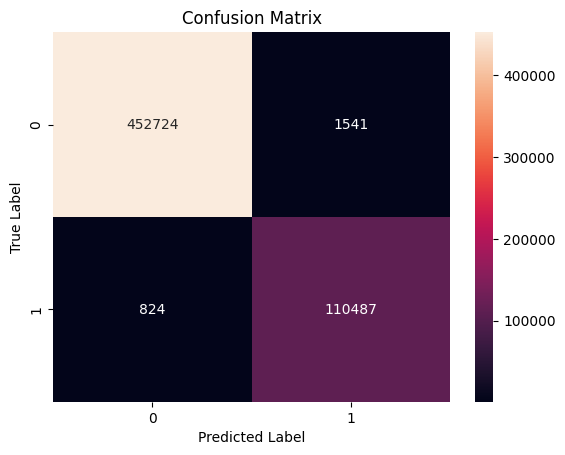

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

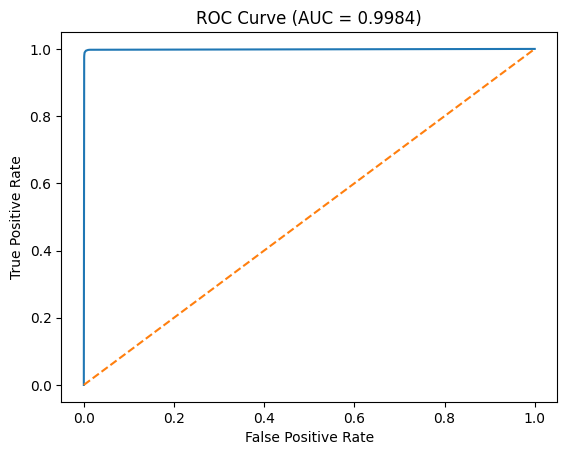

In [15]:
y_probs = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

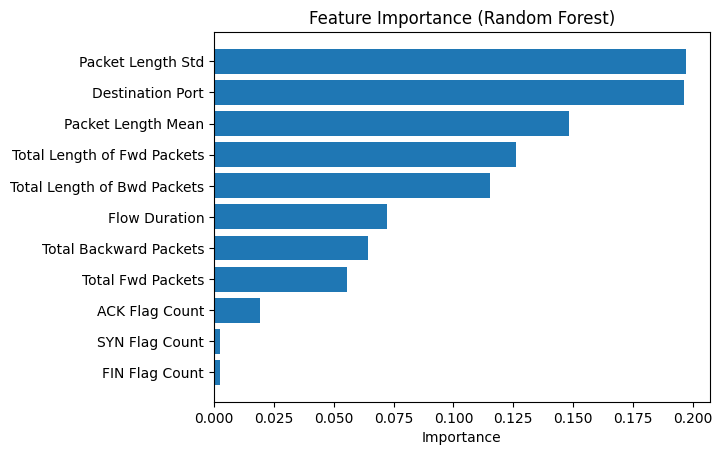

['rf_model.pkl']

In [16]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

joblib.dump(rf, "rf_model.pkl")

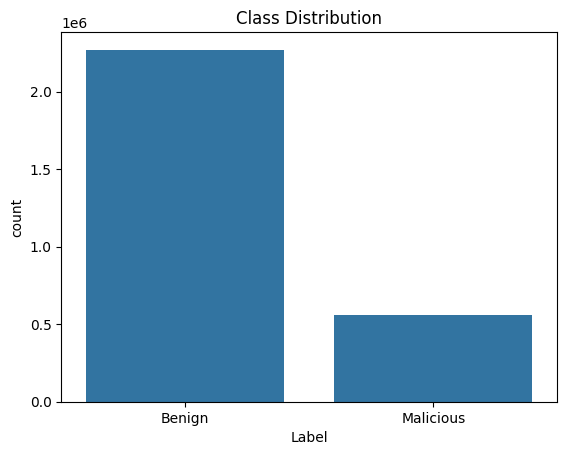

ROC AUC: 0.9984092808885187


In [17]:
plt.figure()
sns.countplot(x=y)
plt.xticks([0,1], ["Benign", "Malicious"])
plt.title("Class Distribution")
plt.show()

print("ROC AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

In [18]:
df['Label'].value_counts(normalize=True)

Label
0    0.803189
1    0.196811
Name: proportion, dtype: float64

In [19]:
print(confusion_matrix(y_test, y_pred))

[[452724   1541]
 [   824 110487]]


In [20]:
y_probs = rf.predict_proba(X_test)[:,1]
print(min(y_probs), max(y_probs))
print(y_probs[:20])

0.0 1.0
[1.         1.         0.99999991 0.         0.99999991 0.9984162
 0.9984162  0.         0.         0.         0.         0.55919007
 0.         0.         0.         0.         0.         0.
 0.         0.        ]


In [21]:
joblib.dump(features, "features.pkl")

['features.pkl']

In [22]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.9820696069140133


In [23]:
print(X_train.shape, y_train.shape)
print(y_train[:10])
print(df['Label'][:10])

(2262300, 11) (2262300,)
1353797    0
292554     0
388802     1
2592587    0
1701321    0
641796     0
29850      1
2260398    1
2405784    1
2561612    0
Name: Label, dtype: int64
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: Label, dtype: int64
